#Linear Regression
- tries to model the relationship between input(X) and output(Y) using a straight line.
- Linear Equation: y = mx+c
- LR assumes a straight-line relationship between the cause and effect.

**NOTE**
- there are infinitely many straight lines that can pass through the data, but WHICH LINE FITS THE DATA BEST??? -> **OLS**

#OLS (ORDINARY LEAST SQUARES)
- OLS is a method(estimation technique) that finds the line that minimizes the total squared error between actual and predicted values.

- It calculates the parameters(slope and intercept) by minimizing the sum of squared differences(errors) between observed actual values and the values predicted by the line.

- KEY WORDS:
   - Ordinary -> standard
   - Least -> minimize
   - Squares -> square the **errors**

- Error:
  - difference between Actual - Predicted

#WHY DO WE Square ERRORS?

- **Avoid Cancellation**
   - Positive and Negative errors cancel out if not squared.

- **Penalize Large Mistake**
   - Big errors become much bigger when squared.
  
- **Math becomes solvable**

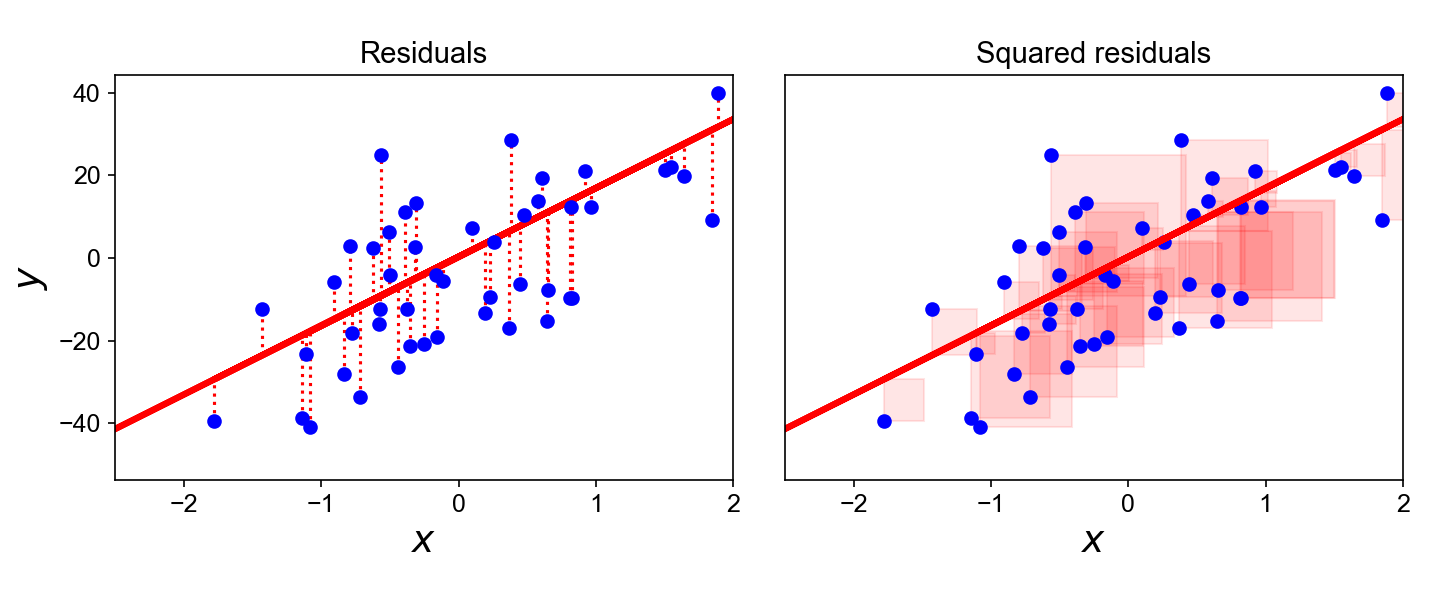

- OLS regression line ALWAYS passes through(mean of X, mean of Y)

##Why "mean" matters so much in OLS?
 - OLS balances errors above the line and below the line

 - AT THE BEST POSITION:
    - Positive and negative deviations are balanced
    - Mean becomes the anchor

In [ ]:
# suppose total error is 4
# one line gave error top 1 and bottom 3
# other line gave top 2 and bottom 2
# so if we square
# 1 and 3 =10
# 2 and 2 = 8
# so 2 and 2 error on both side has less error and balance well

In [ ]:
# dataset link - https://drive.google.com/file/d/1Cl1fsC8Ldbx_74pVPC7zERD4fFx2Wscq/view?usp=sharing

In [ ]:
#1. Data Loading
#2. Data Exploration
#3. Data Preprocessing - EDA
#4. Data Visualization  - 3,4 plots excluding (RegPlot)
#5. Model Building (Regplot)
#6. Take user input for years of experience and predict their salary according to the model

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/Salary_dataset.csv")
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
#1. null values

In [ ]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [ ]:
# 2. duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Salary'].unique()

array([ 39344.,  46206.,  37732.,  43526.,  39892.,  56643.,  60151.,
        54446.,  64446.,  57190.,  63219.,  55795.,  56958.,  57082.,
        61112.,  67939.,  66030.,  83089.,  81364.,  93941.,  91739.,
        98274., 101303., 113813., 109432., 105583., 116970., 112636.,
       122392., 121873.])

In [ ]:
df['Salary'].nunique()

30

In [ ]:
df['YearsExperience'].unique()

array([ 1.2,  1.4,  1.6,  2.1,  2.3,  3. ,  3.1,  3.3,  3.8,  4. ,  4.1,
        4.2,  4.6,  5. ,  5.2,  5.4,  6. ,  6.1,  6.9,  7.2,  8. ,  8.3,
        8.8,  9.1,  9.6,  9.7, 10.4, 10.6])

In [ ]:
df['YearsExperience'].nunique()

28

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

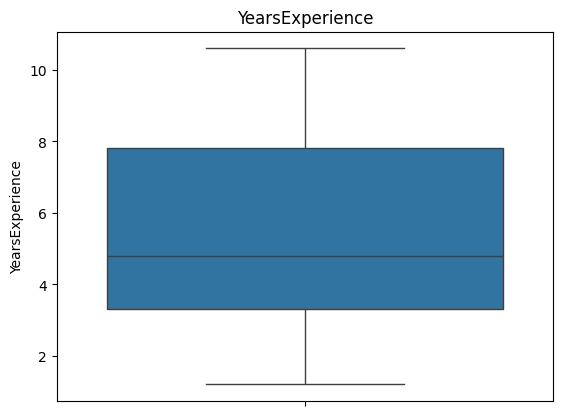

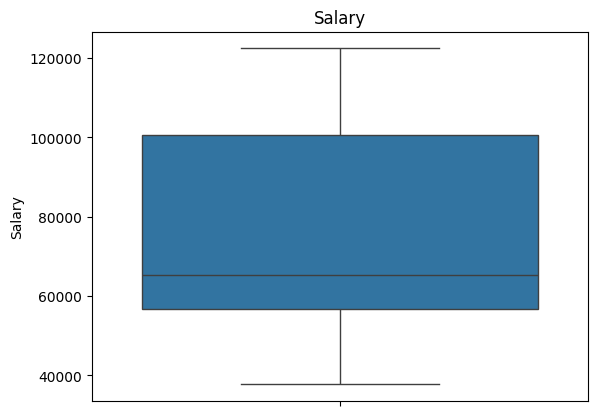

In [ ]:
for col in df.columns:
  if df[col].dtype!='object':
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [ ]:
#create a subplot for 2 graphs
#displaying a KDE histplot using sns for YearsExperience, Salary

In [ ]:
#KDE: Kernel Density Estimation(smoother version of a histogram)

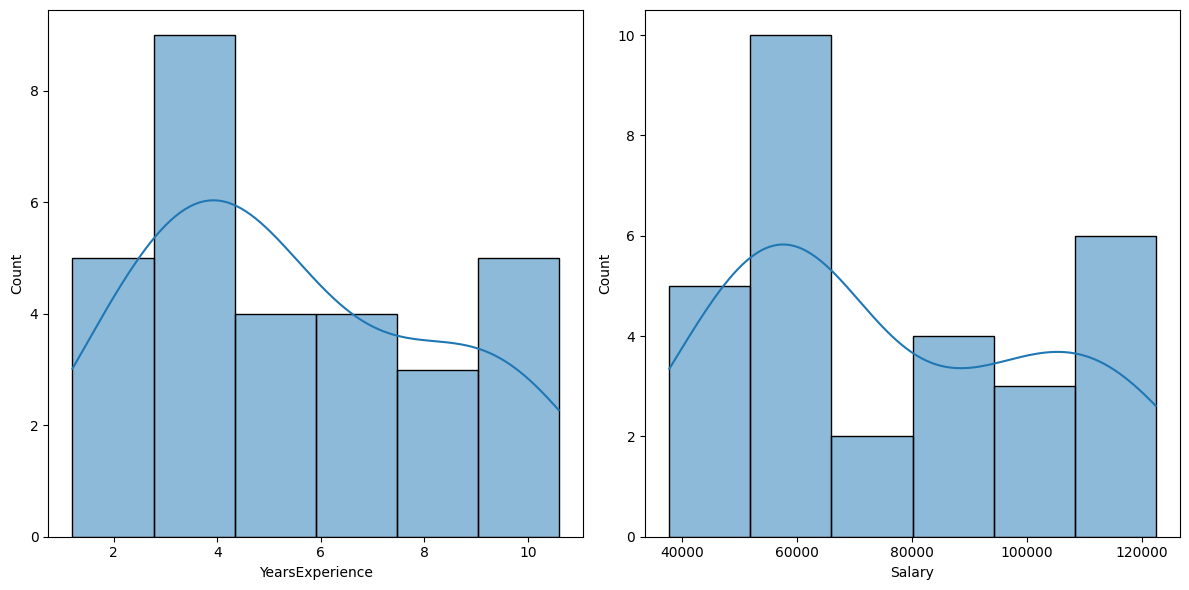

In [ ]:
fig,ax=plt.subplots(1,2, figsize=(12,6))
sns.histplot(df['YearsExperience'], kde=True, ax=ax[0])
sns.histplot(df['Salary'], kde=True, ax=ax[1])
plt.tight_layout()
plt.show()

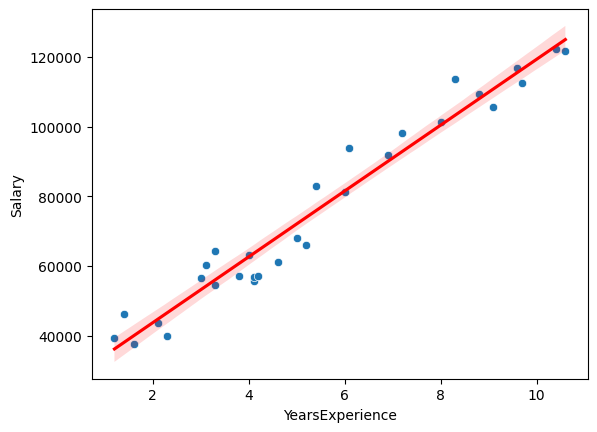

In [ ]:
sns.scatterplot(data=df,x='YearsExperience',y='Salary')
sns.regplot(data=df,x='YearsExperience',y='Salary', scatter=False, color='red')
plt.show()

In [ ]:
#----MODEL BUILDING----

In [ ]:
#1. splitting data into x and y

x=df[['YearsExperience']]
y=df[['Salary']]

In [ ]:
x

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [ ]:
y

,Salary
0,39344.0
1,46206.0
2,37732.0
3,43526.0
4,39892.0
5,56643.0
6,60151.0
7,54446.0
8,64446.0
9,57190.0


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y, train_size=0.80, random_state=10)


In [ ]:
x_train

,YearsExperience
13,4.2
27,9.7
12,4.1
1,1.4
19,6.1
14,4.6
18,6.0
6,3.1
11,4.1
23,8.3


In [ ]:
x_test

,YearsExperience
20,6.9
7,3.3
5,3.0
2,1.6
3,2.1
21,7.2


In [ ]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
from sklearn.metrics import *

r2_score(y_pred,y_test)
#r2score: statistical measure that represents the proportion of the variance for a dependent variable that is explained by an independent variable
#represents the goodness of fit of a regression model

0.9772735206341413

<Axes: ylabel='Salary'>

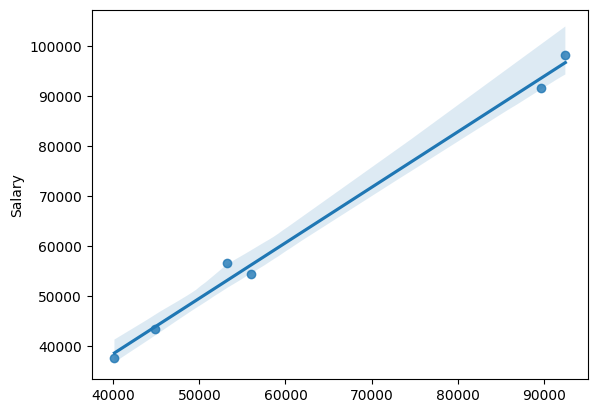

In [ ]:
sns.regplot(x=y_pred,y=y_test)

In [ ]:
#Take user input for years of experience
#predict their salary according to the model

In [ ]:
user_input=float(input("Enter your years of experience: "))

x_test2=pd.DataFrame([user_input])

y_pred=lr.predict(x_test2)

print("The predicted salary for the user is : ", y_pred)

Enter your years of experience: 5.8
The predicted salary for the user is :  [[79424.21569559]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#OLS PDF: https://drive.google.com/file/d/1mtJ_I6Sa59g1C1JfAho8MkyC8WlL6dbg/view?usp=sharing